In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("/content/archive(2).zip")
df

,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0
1,20.57,17.77,132.90,1326.0,0.08474,0
2,19.69,21.25,130.00,1203.0,0.10960,0
3,11.42,20.38,77.58,386.1,0.14250,0
4,20.29,14.34,135.10,1297.0,0.10030,0
...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0
565,20.13,28.25,131.20,1261.0,0.09780,0
566,16.60,28.08,108.30,858.1,0.08455,0
567,20.60,29.33,140.10,1265.0,0.11780,0


In [ ]:
df.isna().sum(0)

mean_radius        0
mean_texture       0
mean_perimeter     0
mean_area          0
mean_smoothness    0
diagnosis          0
dtype: int64

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   mean_radius      569 non-null    float64
 1   mean_texture     569 non-null    float64
 2   mean_perimeter   569 non-null    float64
 3   mean_area        569 non-null    float64
 4   mean_smoothness  569 non-null    float64
 5   diagnosis        569 non-null    int64  
dtypes: float64(5), int64(1)
memory usage: 26.8 KB


In [ ]:
df.describe()

,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,diagnosis
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,1.000000


array([[<Axes: title={'center': 'mean_radius'}>,
        <Axes: title={'center': 'mean_texture'}>],
       [<Axes: title={'center': 'mean_perimeter'}>,
        <Axes: title={'center': 'mean_area'}>],
       [<Axes: title={'center': 'mean_smoothness'}>,
        <Axes: title={'center': 'diagnosis'}>]], dtype=object)

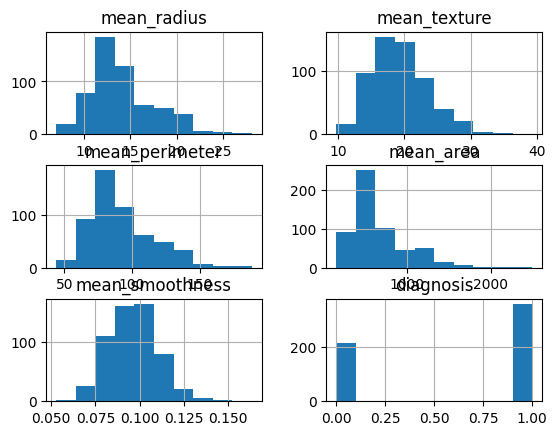

In [ ]:
df.hist()

In [ ]:
df["diagnosis"].value_counts()

diagnosis
1    357
0    212
Name: count, dtype: int64

In [ ]:
X = df.drop(columns = "diagnosis", axis=1)
Y= df["diagnosis"]

In [ ]:
X.head()

,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness
0,17.99,10.38,122.80,1001.0,0.11840
1,20.57,17.77,132.90,1326.0,0.08474
2,19.69,21.25,130.00,1203.0,0.10960
3,11.42,20.38,77.58,386.1,0.14250
4,20.29,14.34,135.10,1297.0,0.10030


In [ ]:
Y.head()

0    0
1    0
2    0
3    0
4    0
Name: diagnosis, dtype: int64

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=2)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.fit_transform(X_test)

In [ ]:
X_train

array([[ 1.94029252,  0.85536022,  1.81300604,  2.05198148, -0.12447086],
       [-0.54671184, -1.21003611, -0.59777015, -0.54641339, -1.33018162],
       [-0.73503734, -0.20269437, -0.75741621, -0.69527115, -0.18354642],
       ...,
       [-0.57994575, -0.09896353, -0.62149589, -0.59079506, -0.86611821],
       [ 0.54723774,  0.31134958,  0.64280442,  0.38367194,  1.49263353],
       [ 0.53062078,  0.07392121,  0.48195196,  0.43577215, -0.30952682]])

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix,accuracy_score,roc_curve,classification_report



In [ ]:
m1="Logistic Regression"
lr_model = LogisticRegression(solver="liblinear",random_state=2 )
# training the model with training data
lr_model.fit(X_train, y_train)



LogisticRegression(random_state=2, solver='liblinear')

In [ ]:
# Accuracy on test data
X_test_prediction = lr_model.predict(X_test)
test_data_accuracy_lr = accuracy_score(X_test_prediction, y_test)
print(f"Accuracy on Test data: ",test_data_accuracy_lr*100)


Accuracy on Test data:  93.85964912280701


In [ ]:
# Accuracy on test data
X_test_prediction = lr_model.predict(X_test)
test_data_accuracy_lr = accuracy_score(X_test_prediction, y_test)
print(f"Accuracy on Training data: ",test_data_accuracy_lr*100)


Accuracy on Training data:  93.85964912280701


In [ ]:

#Confussion matrix
LR_conf_matrix = confusion_matrix(y_test, X_test_prediction)
print("Confussion matrix")
print(LR_conf_matrix)

Confussion matrix
[[38  4]
 [ 3 69]]


In [ ]:
from sklearn.svm import SVC
m7="svc"
svc = SVC(C=5,kernel="rbf")
svc.fit(X_train, y_train)
# Accuracy on training data
X_train_predict= svc.predict(X_train)
training_data_accuracy=accuracy_score(X_train_predict, y_train)
print(f"Accuracy on Training data: ",training_data_accuracy*100)
# Accuracy on test data
X_test_predict= svc.predict(X_test)
test_data_accuracy_svc=accuracy_score(X_test_predict, y_test)
print(f"Accuracy on Test data: ",test_data_accuracy_svc*100)
#Confussion matrix
knn_confusion_matrix =  confusion_matrix(y_test,X_test_predict)
print("Confusion Matrix")
print(knn_confusion_matrix)

Accuracy on Training data:  94.28571428571428
Accuracy on Test data:  92.98245614035088
Confusion Matrix
[[38  4]
 [ 4 68]]


In [ ]:
from tensorflow.keras import layers, models

# Create a simple neural network
model = models.Sequential([
    layers.Dense(13, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dense(5, activation='relu'),
    layers.Dense(1, activation='sigmoid')  # Binary classification, hence 1 output node with sigmoid activation
])

# Compile the model
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Train the model
history=model.fit(X_train, y_train, epochs=20, batch_size=8, validation_split=0.1)

Epoch 1/20
52/52 [==============================] - 2s 10ms/step - loss: 0.7396 - accuracy: 0.4279 - val_loss: 0.6274 - val_accuracy: 0.7391
Epoch 2/20
52/52 [==============================] - 0s 3ms/step - loss: 0.5706 - accuracy: 0.7824 - val_loss: 0.4609 - val_accuracy: 0.8478
Epoch 3/20
52/52 [==============================] - 0s 3ms/step - loss: 0.4537 - accuracy: 0.8313 - val_loss: 0.3590 - val_accuracy: 0.9130
Epoch 4/20
52/52 [==============================] - 0s 3ms/step - loss: 0.3729 - accuracy: 0.8557 - val_loss: 0.2970 - val_accuracy: 0.9130
Epoch 5/20
52/52 [==============================] - 0s 3ms/step - loss: 0.3161 - accuracy: 0.8778 - val_loss: 0.2605 - val_accuracy: 0.9130
Epoch 6/20
52/52 [==============================] - 0s 3ms/step - loss: 0.2757 - accuracy: 0.8973 - val_loss: 0.2342 - val_accuracy: 0.9130
Epoch 7/20
52/52 [==============================] - 0s 3ms/step - loss: 0.2474 - accuracy: 0.9071 - val_loss: 0.2148 - val_accuracy: 0.9130
Epoch 8/20
52/52 [=

In [ ]:
# Evaluate the model on the test data
loss, accuracy = model.evaluate(X_test, y_test)
print("Test accuracy:", accuracy)


4/4 [==============================] - 0s 4ms/step - loss: 0.1599 - accuracy: 0.9386
Test accuracy: 0.9385964870452881


4/4 - 0s - loss: 0.1599 - accuracy: 0.9386 - 27ms/epoch - 7ms/step


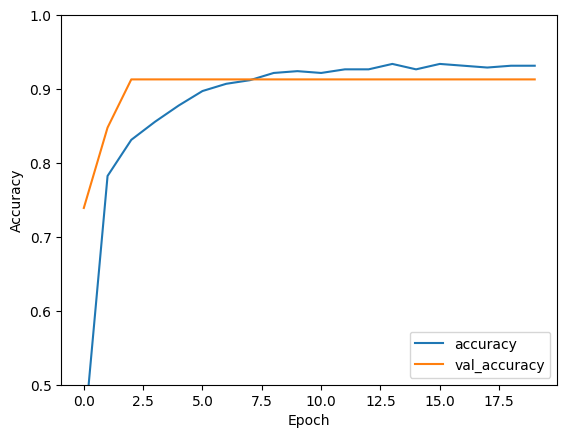

In [ ]:
plt.plot(history.history['accuracy'],label='accuracy')
plt.plot(history.history['val_accuracy'],label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.5, 1])
plt.legend(loc='lower right')

test_loss, test_acc = model.evaluate(X_test,
                                     y_test,
                                     verbose=2)

In [ ]:
test_loss

0.15988405048847198

In [ ]:
from tensorflow.keras import layers,models
#create a simple neural network
model=models.Sequential([
    layers.Dense(13,activation='relu',input_shape=(X_train.shape[1],)),
    layers.Dense(7,activation='relu'),
    layers.Dense(5,activation='relu'),
    layers.Dense(55,activation='relu'),
    layers.Dense(77,activation='relu'),
    layers.Dense(1,activation='sigmoid')
])

In [ ]:
model.compile(optimizer='adam',
             loss='binary_crossentropy',
             metrics=['accuracy'])
history=model.fit(X_train,y_train, epochs=100, batch_size=8, validation_split=0.1)

Epoch 1/100
52/52 [==============================] - 2s 7ms/step - loss: 0.5809 - accuracy: 0.6186 - val_loss: 0.3968 - val_accuracy: 0.6304
Epoch 2/100
52/52 [==============================] - 0s 3ms/step - loss: 0.3583 - accuracy: 0.8778 - val_loss: 0.2812 - val_accuracy: 0.9130
Epoch 3/100
52/52 [==============================] - 0s 3ms/step - loss: 0.2692 - accuracy: 0.9267 - val_loss: 0.2126 - val_accuracy: 0.9565
Epoch 4/100
52/52 [==============================] - 0s 4ms/step - loss: 0.2145 - accuracy: 0.9315 - val_loss: 0.1745 - val_accuracy: 0.9565
Epoch 5/100
52/52 [==============================] - 0s 3ms/step - loss: 0.1879 - accuracy: 0.9291 - val_loss: 0.1571 - val_accuracy: 0.9348
Epoch 6/100
52/52 [==============================] - 0s 3ms/step - loss: 0.1807 - accuracy: 0.9315 - val_loss: 0.1429 - val_accuracy: 0.9565
Epoch 7/100
52/52 [==============================] - 0s 4ms/step - loss: 0.1653 - accuracy: 0.9340 - val_loss: 0.1443 - val_accuracy: 0.9783
Epoch 8/100
5

In [ ]:
import tensorflow as tf
from tensorflow.keras import datasets, layers,models
import matplotlib.pyplot as plt

In [ ]:
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()
train_images, test_images = train_images/255.0, test_images/255.0

170498071/170498071 [==============================] - 2s 0us/step


In [ ]:
model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2,2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))

In [ ]:
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10))

In [ ]:
model.summary()

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_6 (Conv2D)           (None, 30, 30, 32)        896       
                                                                 
 max_pooling2d_4 (MaxPoolin  (None, 15, 15, 32)        0         
 g2D)                                                            
                                                                 
 conv2d_7 (Conv2D)           (None, 13, 13, 64)        18496     
                                                                 
 max_pooling2d_5 (MaxPoolin  (None, 6, 6, 64)          0         
 g2D)                                                            
                                                                 
 conv2d_8 (Conv2D)           (None, 4, 4, 64)          36928     
                                                                 
 flatten (Flatten)           (None, 1024)             

In [ ]:
# Adam is the best among the adaptive optimizers in most of the cases
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

# An epoch means training the neural network with all the
# training data for one cycle. Here I use 10 epochs
history = model.fit(train_images, train_labels, epochs=10,
                    validation_data=(test_images, test_labels))

Epoch 1/10
1563/1563 [==============================] - 83s 52ms/step - loss: 0.6256 - accuracy: 0.7807 - val_loss: 0.8920 - val_accuracy: 0.7039
Epoch 2/10
1563/1563 [==============================] - 74s 47ms/step - loss: 0.5928 - accuracy: 0.7893 - val_loss: 0.8974 - val_accuracy: 0.7111
Epoch 3/10
1563/1563 [==============================] - 74s 47ms/step - loss: 0.5626 - accuracy: 0.8013 - val_loss: 0.9012 - val_accuracy: 0.7083
Epoch 4/10
1563/1563 [==============================] - 75s 48ms/step - loss: 0.5307 - accuracy: 0.8126 - val_loss: 0.9398 - val_accuracy: 0.7055
Epoch 5/10
1563/1563 [==============================] - 73s 47ms/step - loss: 0.5113 - accuracy: 0.8205 - val_loss: 0.9504 - val_accuracy: 0.7035
Epoch 6/10
1563/1563 [==============================] - 73s 47ms/step - loss: 0.4810 - accuracy: 0.8293 - val_loss: 0.9815 - val_accuracy: 0.6975
Epoch 7/10
1563/1563 [==============================] - 78s 50ms/step - loss: 0.4627 - accuracy: 0.8352 - val_loss: 0.9844 -